<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec08_kmean_cluster_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering (학생용)

이 과제에서는 K-Means 클러스터링을 학습합니다:
1. scikit-learn을 이용한 K-Means 기본 사용법
2. K-Means 알고리즘 직접 구현 (From Scratch)

**K-Means 알고리즘 개요:**
1. K개의 초기 중심점(centroid)을 랜덤하게 선택
2. 각 데이터 포인트를 **가장 가까운** 중심점의 클러스터에 할당
3. 각 클러스터에 속한 데이터의 **평균**으로 중심점 재계산
4. 중심점이 변하지 않을 때까지 2~3 반복


---
**학번:** 2023042028\
**이름:** 권택주


---
## Part 1: 데이터셋 생성

클러스터링 실습을 위한 데이터셋을 생성합니다.  
`make_blobs`는 여러 개의 가우시안 분포에서 샘플을 생성하여 클러스터링 실습에 적합한 데이터를 만들어 줍니다.

> 이 단계에서는 **레이블(정답) 정보를 사용하지 않고** 데이터를 있는 그대로 시각화합니다.  
> 클러스터링의 목표는 레이블 없이 데이터의 구조를 스스로 찾아내는 것입니다.

---

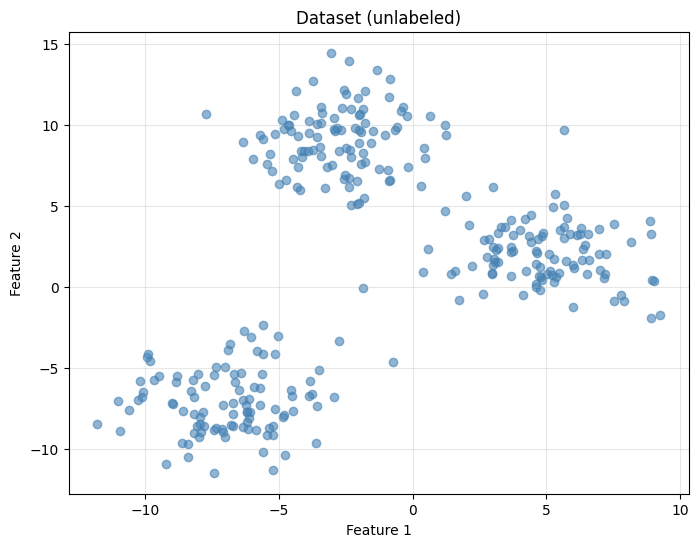

Dataset: 300 samples, 2 features


In [1]:
#@title { vertical-output: true}
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(42)

# Blob 데이터셋 생성 (3개 클러스터)
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=2, random_state=42)

# 시각화 (클러스터 구분 없이 단일 색상으로 표시)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='steelblue', alpha=0.6)
plt.title('Dataset (unlabeled)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")

---
## Part 2: scikit-learn K-Means (20점)

scikit-learn의 `KMeans`를 사용하여 클러스터링을 수행합니다.

### KMeans 주요 파라미터

| 파라미터 | 설명 |
|----------|------|
| `n_clusters` | 클러스터 개수 K |
| `random_state` | 재현성을 위한 랜덤 시드 |
| `n_init` | 다른 초기 중심점으로 알고리즘을 실행할 횟수 (기본값 10) |

### 주요 메서드 및 속성

```python
kmeans.fit_predict(X)      # 학습 + 클러스터 레이블 반환
kmeans.cluster_centers_    # 최종 중심점 좌표 (k, n_features)
kmeans.inertia_            # Inertia (클러스터 내 거리 제곱합)
```

---

### 문제 2-1. K-Means 클러스터링 수행 [20점]

**문제:** `KMeans` 모델을 생성하고, 데이터에 대해 클러스터링을 수행하세요.

**조건:**
- `n_clusters = 3`
- `random_state = 42`
- `n_init = 10`

**예상 결과:**
```
Inertia: 2267.44
Cluster Centers:
  Cluster 0: (-2.80, 8.98)
  Cluster 1: ( 4.85, 2.05)
  Cluster 2: (-6.89, -7.09)
```
그리고 3개의 클러스터가 색상으로 구분되고, 빨간 X 표시로 중심점이 나타납니다.

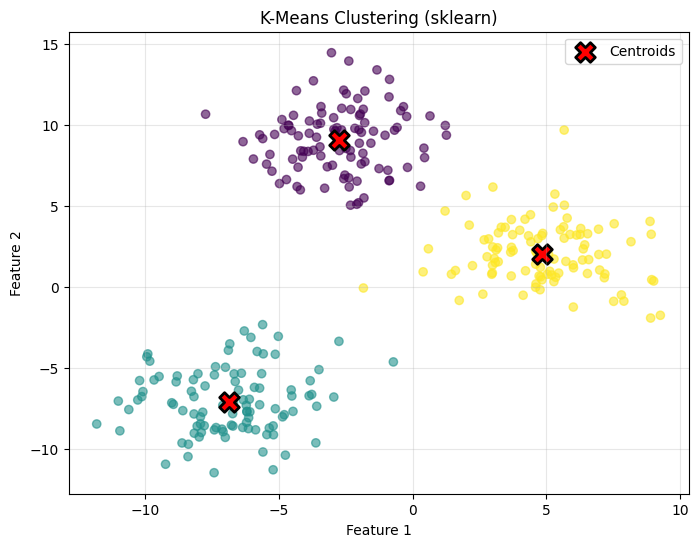

Inertia: 2267.44

Cluster Centers:
  Cluster 0: (-2.76, 9.07)
  Cluster 1: (-6.89, -7.09)
  Cluster 2: (4.85, 2.05)


In [3]:
#@title { vertical-output: true}
from sklearn.cluster import KMeans

# IMPLEMENT HERE: KMeans 모델 생성 및 학습
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X)

# IMPLEMENT HERE: 중심점 추출
centers = kmeans.cluster_centers_

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.6)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200,
            edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering (sklearn)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"\nCluster Centers:")
for i, c in enumerate(centers):
    print(f"  Cluster {i}: ({c[0]:.2f}, {c[1]:.2f})")

---
## Part 3: K-Means From Scratch (80점)

K-Means 알고리즘을 직접 구현합니다.  
아래 수식을 참고하여 각 함수를 완성하세요.

### 유클리드 거리

두 점 $x = (x_1, x_2, \ldots, x_n)$과 $y = (y_1, y_2, \ldots, y_n)$ 사이의 거리:

$$d(x, y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$$

### 중심점 업데이트

클러스터 $C_k$에 속한 모든 데이터의 평균으로 중심점을 갱신합니다:

$$\mu_k = \frac{1}{|C_k|}\sum_{x \in C_k} x$$

---

### 문제 3-1. 유클리드 거리 계산 [15점]

**문제:** 두 점 사이의 유클리드 거리를 계산하는 함수를 구현하세요.

$$d(x_1, x_2) = \sqrt{\sum_{i}(x_{1i} - x_{2i})^2}$$

**구현 힌트:**
- `np.sum(...)`: 원소 합산
- `np.sqrt(...)`: 제곱근

**예상 결과:**
```
Distance between [0 0] and [3 4]: 5.0
```

In [5]:
#@title { vertical-output: true}
def euclidean_distance(x1, x2):
    """
    두 점 사이의 유클리드 거리 계산

    Parameters:
    - x1: 첫 번째 점 (array)
    - x2: 두 번째 점 (array)

    Returns:
    - distance: 유클리드 거리 (scalar)
    """
    # IMPLEMENT HERE
    distance = np.sqrt(np.sum((x1 - x2) ** 2))
    return distance


# 검증
p1 = np.array([0, 0])
p2 = np.array([3, 4])
print(f"Distance between {p1} and {p2}: {euclidean_distance(p1, p2)}")  # 5.0 이어야 합니다

Distance between [0 0] and [3 4]: 5.0


### 문제 3-2. 가장 가까운 중심점 찾기 [20점]

**문제:** 각 데이터 포인트에 대해 가장 가까운 중심점의 인덱스를 반환하는 함수를 구현하세요.

**알고리즘:**
1. 각 데이터 포인트 `x`에 대해
2. 모든 중심점 `c`까지의 유클리드 거리를 계산
3. 거리가 가장 작은 중심점의 인덱스를 레이블로 저장

**구현 힌트:**
- `euclidean_distance(x, c)`: 앞서 구현한 함수 활용
- `np.argmin(distances)`: 최솟값의 인덱스 반환

**예상 결과:**
```
Labels: [0 1 0]
# [1,1]과 [0,1]은 [0,0]에 가깝고, [4,4]는 [5,5]에 가깝습니다.
```

In [6]:
#@title { vertical-output: true}
def find_closest_centroid(X, centroids):
    """
    각 데이터 포인트에 대해 가장 가까운 중심점의 인덱스 반환

    Parameters:
    - X: 데이터 (n_samples, n_features)
    - centroids: 중심점들 (k, n_features)

    Returns:
    - labels: 각 데이터 포인트의 클러스터 인덱스 (n_samples,)
    """
    labels = []
    for x in X:
        # IMPLEMENT HERE
        # 1. 모든 중심점까지의 거리를 리스트로 계산
        distances = [euclidean_distance(x, c) for c in centroids]
        # 2. 가장 가까운 중심점의 인덱스를 labels에 추가
        labels.append(np.argmin(distances))
    return np.array(labels)

# 검증
test_centroids = np.array([[0, 0], [5, 5]])
test_X = np.array([[1, 1], [4, 4], [0, 1]])
print(f"Labels: {find_closest_centroid(test_X, test_centroids)}")  # [0 1 0] 이어야 합니다

Labels: [0 1 0]


### 문제 3-3. 중심점 업데이트 [20점]

**문제:** 각 클러스터에 속한 데이터 포인트들의 평균으로 중심점을 업데이트하는 함수를 구현하세요.

$$\mu_k = \frac{1}{|C_k|}\sum_{x \in C_k} x$$

**알고리즘:**
1. 클러스터 번호 `i = 0, 1, ..., k-1` 에 대해
2. `labels == i`인 데이터 포인트들을 추출
3. 해당 포인트들의 평균을 새로운 중심점으로 사용
4. (예외 처리) 클러스터가 비어있으면 랜덤 데이터를 중심점으로 사용

**구현 힌트:**
- `X[labels == i]`: i번 클러스터에 속한 데이터 필터링
- `np.mean(..., axis=0)`: 행 방향 평균

**예상 결과:**
```
Updated centroids:
[[0.5  1. ]   ← cluster 0의 [1,1], [0,1] 평균
 [4.   4. ]]  ← cluster 1의 [4,4] 평균
```

In [7]:
#@title { vertical-output: true}
def update_centroids(X, labels, k):
    """
    각 클러스터의 중심점 업데이트

    Parameters:
    - X: 데이터 (n_samples, n_features)
    - labels: 각 데이터 포인트의 클러스터 인덱스
    - k: 클러스터 개수

    Returns:
    - new_centroids: 업데이트된 중심점들 (k, n_features)
    """
    new_centroids = []
    for i in range(k):
        # IMPLEMENT HERE
        # 1. i번 클러스터에 속한 데이터 추출
        cluster_points = X[labels == i]
        # 2. 클러스터가 비어있지 않으면 평균, 비어있으면 랜덤 데이터 선택
        if len(cluster_points) > 0:
            new_centroids.append(np.mean(cluster_points, axis=0))
        else:
            random = np.random.randint(X.shape[0])
            new_centroids.append(random)

    return np.array(new_centroids)

# 검증
test_labels = np.array([0, 1, 0])
new_cents = update_centroids(test_X, test_labels, 2)
print(f"Updated centroids:\n{new_cents}")
# [[0.5  1. ]
#  [4.   4. ]] 이어야 합니다

Updated centroids:
[[0.5 1. ]
 [4.  4. ]]


### 문제 3-4. K-Means 전체 알고리즘 구현 [25점]

**문제:** 앞서 구현한 함수들을 조합하여 K-Means 알고리즘 전체를 구현하세요.

**알고리즘 흐름:**

```
① 초기 중심점 k개를 데이터에서 랜덤하게 선택
② for i in range(max_iters):
      ③ 각 데이터를 가장 가까운 중심점에 할당 → labels
      ④ 중심점 업데이트 → new_centroids
      ⑤ 이전 중심점과 새 중심점이 같으면 수렴 → 조기 종료
      ⑥ centroids = new_centroids
```

**구현 힌트:**
- 초기 중심점: `np.random.choice(len(X), k, replace=False)` → 인덱스 추출 후 `X[idx]`
- 수렴 확인: `np.allclose(centroids, new_centroids)`

**예상 결과:**
```
Converged in 4 iterations
Cluster Centers (from scratch):
  Cluster 0: (-2.76,  9.07)
  Cluster 1: (-6.89, -7.09)
  Cluster 2: ( 4.85,  2.05)
```

In [8]:
#@title { vertical-output: true}
def kmeans_scratch(X, k, max_iters=100, random_state=42):
    """
    K-Means 알고리즘 구현

    Parameters:
    - X: 데이터 (n_samples, n_features)
    - k: 클러스터 개수
    - max_iters: 최대 반복 횟수
    - random_state: 랜덤 시드

    Returns:
    - labels: 최종 클러스터 레이블
    - centroids: 최종 중심점
    - n_iters: 수렴까지 반복 횟수
    """
    np.random.seed(random_state)

    # IMPLEMENT HERE: 초기 중심점 랜덤 선택 (데이터에서 k개 인덱스 추출)
    idx = np.random.choice(len(X), k, replace=False)
    centroids = X[idx]

    for i in range(max_iters):
        # IMPLEMENT HERE: 가장 가까운 중심점 찾기
        labels = find_closest_centroid(X, centroids)

        # IMPLEMENT HERE: 중심점 업데이트
        new_centroids = update_centroids(X, labels, k)

        # 수렴 확인
        if np.allclose(centroids, new_centroids):
            return labels, new_centroids, i + 1

        # IMPLEMENT HERE: 중심점 갱신
        centroids = new_centroids

    return labels, centroids, max_iters

# K-Means 실행
labels_scratch, centers_scratch, n_iters = kmeans_scratch(X, k=3, random_state=42)
print(f"Converged in {n_iters} iterations")
print(f"\nCluster Centers (from scratch):")
for i, c in enumerate(centers_scratch):
    print(f"  Cluster {i}: ({c[0]:.2f}, {c[1]:.2f})")

Converged in 4 iterations

Cluster Centers (from scratch):
  Cluster 0: (-2.76, 9.07)
  Cluster 1: (-6.89, -7.09)
  Cluster 2: (4.85, 2.05)


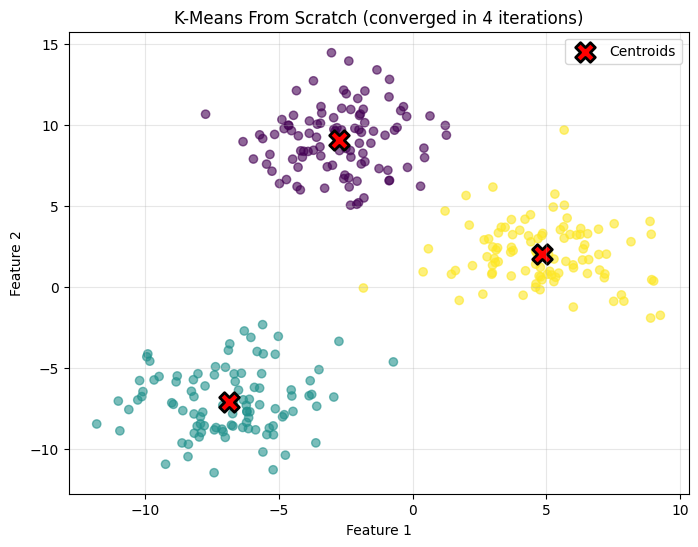

In [9]:
#@title { vertical-output: true}
# K-Means From Scratch 결과 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_scratch, cmap='viridis', alpha=0.6)
plt.scatter(centers_scratch[:, 0], centers_scratch[:, 1], c='red', marker='X', s=200,
            edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'K-Means From Scratch (converged in {n_iters} iterations)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 제출 안내

### 제출 파일
1. **`.ipynb` 파일**: 모든 셀을 실행한 상태로 저장
2. **`.pdf` 파일**: 파일 → 인쇄 → PDF로 저장

### 파일명
```
kmean_cluster_[학번]_[이름].ipynb
kmean_cluster_[학번]_[이름].pdf
```

### 제출 체크리스트
- [ ] Part 2: KMeans 모델 생성 및 클러스터링 완료
- [ ] Part 3-1: `euclidean_distance` 구현 및 검증 통과 (5.0)
- [ ] Part 3-2: `find_closest_centroid` 구현 및 검증 통과 (`[0 1 0]`)
- [ ] Part 3-3: `update_centroids` 구현 및 검증 통과 (`[[0.5 1.] [4. 4.]]`)
- [ ] Part 3-4: `kmeans_scratch` 구현 및 결과 시각화 확인
- [ ] `.ipynb`와 `.pdf` 모두 제출

### LMS 제출
두 파일을 **기한 내에** LMS에 제출하세요.  
> ⚠️ **기한 내에 제출하지 않으면 감점이 있습니다.**

---